<a href="https://colab.research.google.com/github/Yashew/QuantumLeap-2026/blob/main/Quantum_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y qiskit qiskit-nature qiskit-algorithms
!pip install qiskit==1.1.0 qiskit-nature==0.7.2 qiskit-algorithms==0.3.0 pyscf

Hydrogen Molecule

In [7]:
import time
import numpy as np
from qiskit.primitives import Estimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock

#time calculation
start_time = time.time()

#Define H2 Geometry (Å)
geometry = "H 0.0 0.0 0.0; H 0.0 0.0 0.735"

driver = PySCFDriver(
    atom=geometry,
    basis="sto3g",
    charge=0,
    spin=0
)
problem = driver.run()

# Build Qubit Hamiltonian
# ParityMapper + 2-qubit reduction
# reduces H2 from 4 → 2 qubits
second_q_op = problem.hamiltonian.second_q_op()
mapper = ParityMapper(num_particles=problem.num_particles)
qubit_op = mapper.map(second_q_op)

# Prepare Hartree–Fock + UCCSD
num_particles = problem.num_particles
num_spatial_orbitals = problem.num_spatial_orbitals

hf_state = HartreeFock(
    num_spatial_orbitals,
    num_particles,
    mapper
)
ansatz = UCCSD(
    num_spatial_orbitals,
    num_particles,
    mapper,
    initial_state=hf_state
)

# VQE Setup
initial_point = np.zeros(ansatz.num_parameters)

estimator = Estimator()
optimizer = SLSQP(maxiter=200)
vqe = VQE(estimator, ansatz, optimizer, initial_point=initial_point)
result = vqe.compute_minimum_eigenvalue(qubit_op)

# Energies
electronic_energy = result.eigenvalue.real
nuclear_repulsion = problem.nuclear_repulsion_energy
total_energy = electronic_energy + nuclear_repulsion

print("Electronic Energy (Hartree):", electronic_energy)
print("Nuclear Repulsion (Hartree):", nuclear_repulsion)
print("Total Ground State Energy (Hartree):", total_energy)

end_time = time.time()
execution_time = end_time - start_time
print("Execution Time:", execution_time, "seconds")

Electronic Energy (Hartree): -1.8572750301447756
Nuclear Repulsion (Hartree): 0.7199689944489797
Total Ground State Energy (Hartree): -1.1373060356957958
Execution Time: 0.18840336799621582 seconds


LiH

In [8]:
import time
import numpy as np
from qiskit.primitives import Estimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.transformers import FreezeCoreTransformer

#time calculation
start_time = time.time()

# Define LiH Geometry (Å)
geometry = "Li 0.0 0.0 0.0; H 0.0 0.0 1.596"

driver = PySCFDriver(
    atom=geometry,
    basis="sto3g",
    charge=0,
    spin=0
)
problem = driver.run()

# Use FreezeCoreTransformer instead
# of ActiveSpaceTransformer
# This correctly handles the frozen
# core energy contribution
transformer = FreezeCoreTransformer(
    freeze_core=True,
    remove_orbitals=[-1, -2]
)
problem = transformer.transform(problem)

# Build Qubit Hamiltonian
second_q_op = problem.hamiltonian.second_q_op()
mapper = ParityMapper(num_particles=problem.num_particles)
qubit_op = mapper.map(second_q_op)


# Prepare Hartree–Fock + UCCSD
num_particles = problem.num_particles
num_spatial_orbitals = problem.num_spatial_orbitals

hf_state = HartreeFock(
    num_spatial_orbitals,
    num_particles,
    mapper
)
ansatz = UCCSD(
    num_spatial_orbitals,
    num_particles,
    mapper,
    initial_state=hf_state
)


# VQE Setup
initial_point = np.zeros(ansatz.num_parameters)

estimator = Estimator()
optimizer = SLSQP(maxiter=200)
vqe = VQE(estimator, ansatz, optimizer, initial_point=initial_point)
result = vqe.compute_minimum_eigenvalue(qubit_op)


# Energies
# nuclear_repulsion already includes
# frozen core correction
electronic_energy = result.eigenvalue.real
nuclear_repulsion = problem.nuclear_repulsion_energy
total_energy = electronic_energy + nuclear_repulsion

end_time = time.time()
execution_time = end_time - start_time
print("Execution Time:", execution_time, "seconds")

print("Electronic Energy (Hartree):", electronic_energy)
print("Nuclear Repulsion (Hartree):", nuclear_repulsion)
print("Total Ground State Energy (Hartree):", total_energy)

Electronic Energy (Hartree): -1.0789775757915845
Nuclear Repulsion (Hartree): 0.9946940054887219
Total Ground State Energy (Hartree): -0.0842835703028626
Execution Time: 74.573166847229 seconds


Ethane Molecule

In [11]:
import time
import numpy as np
from qiskit.primitives import Estimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

#time calculation
start_time = time.time()

geometry = "\n".join([
    "C 0.0000  0.0000  0.0000",
    "C 1.5400  0.0000  0.0000",
    "H -0.5400  0.9350  0.0000",
    "H -0.5400 -0.4675  0.8090",
    "H -0.5400 -0.4675 -0.8090",
    "H  2.0800  0.4675  0.8090",
    "H  2.0800  0.4675 -0.8090",
    "H  2.0800 -0.9350  0.0000",
])

driver = PySCFDriver(atom=geometry, basis="sto3g", charge=0, spin=0)
problem = driver.run()

transformer = ActiveSpaceTransformer(
    num_electrons=4,
    num_spatial_orbitals=4
)
problem = transformer.transform(problem)

second_q_op = problem.hamiltonian.second_q_op()
mapper = JordanWignerMapper()
qubit_op = mapper.map(second_q_op)

num_particles = problem.num_particles
num_spatial_orbitals = problem.num_spatial_orbitals

hf_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=hf_state)

import numpy as np
initial_point = np.zeros(ansatz.num_parameters)

estimator = Estimator()
optimizer = SLSQP(maxiter=200)
vqe = VQE(estimator, ansatz, optimizer, initial_point=initial_point)
result = vqe.compute_minimum_eigenvalue(qubit_op)

electronic_energy = result.eigenvalue.real
nuclear_repulsion = problem.nuclear_repulsion_energy
total_energy = electronic_energy + nuclear_repulsion

end_time = time.time()
execution_time = end_time - start_time
print("Execution Time:", execution_time, "seconds")

print("Electronic Energy (Hartree):", electronic_energy)
print("Nuclear Repulsion (Hartree):", nuclear_repulsion)
print("Total Ground State Energy (Hartree):", total_energy)

Execution Time: 37.33414912223816 seconds
Electronic Energy (Hartree): -3.8727209628321484
Nuclear Repulsion (Hartree): 41.97036875592376
Total Ground State Energy (Hartree): 38.09764779309161


BeH2

In [14]:
import time
import numpy as np
from qiskit.primitives import Estimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

start_time = time.time()

geometry = "\n".join([
    "Be 0.0000 0.0000 0.0000",
    "H  0.0000 0.0000 1.3264",
    "H  0.0000 0.0000 -1.3264"
])

driver = PySCFDriver(atom=geometry, basis="sto3g", charge=0, spin=0)
problem = driver.run()

transformer = ActiveSpaceTransformer(
    num_electrons=2,
    num_spatial_orbitals=2
)
problem = transformer.transform(problem)

second_q_op = problem.hamiltonian.second_q_op()
mapper = ParityMapper(num_particles=problem.num_particles)
qubit_op = mapper.map(second_q_op)

num_particles = problem.num_particles
num_spatial_orbitals = problem.num_spatial_orbitals

print(f"Qubits         : {qubit_op.num_qubits}")
print(f"UCCSD params   : ", end="")

hf_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=hf_state)
print(ansatz.num_parameters)

initial_point = np.zeros(ansatz.num_parameters)
estimator = Estimator()
optimizer = SLSQP(maxiter=200)
vqe = VQE(estimator, ansatz, optimizer, initial_point=initial_point)
result = vqe.compute_minimum_eigenvalue(qubit_op)

electronic_energy = result.eigenvalue.real
nuclear_repulsion = problem.nuclear_repulsion_energy
total_energy = electronic_energy + nuclear_repulsion

end_time = time.time()
print(f"Execution Time : {end_time - start_time:.2f} seconds")
print(f"Electronic Energy (Hartree) : {electronic_energy}")
print(f"Nuclear Repulsion (Hartree) : {nuclear_repulsion}")
print(f"Total Ground State Energy (Hartree) : {total_energy}")

Qubits         : 2
UCCSD params   : 3
Execution Time : 0.26 seconds
Electronic Energy (Hartree) : -1.280496176928305
Nuclear Repulsion (Hartree) : 3.391138640545839
Total Ground State Energy (Hartree) : 2.110642463617534


In [15]:
#Running BeH2 with 2,4,6 qubits and finding time for execution

import time
import numpy as np
from qiskit.primitives import Estimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

def run_beh2_vqe(n_spatial_orbitals_for_transformer):
    start_time = time.time()

    geometry = "\n".join([
        "Be 0.0000 0.0000 0.0000",
        "H  0.0000 0.0000 1.3264",
        "H  0.0000 0.0000 -1.3264"
    ])

    driver = PySCFDriver(atom=geometry, basis="sto3g", charge=0, spin=0)
    problem = driver.run()

    transformer = ActiveSpaceTransformer(
        num_electrons=2,
        num_spatial_orbitals=n_spatial_orbitals_for_transformer
    )
    problem = transformer.transform(problem)

    second_q_op = problem.hamiltonian.second_q_op()
    mapper = ParityMapper(num_particles=problem.num_particles)
    qubit_op = mapper.map(second_q_op)

    num_particles = problem.num_particles
    num_spatial_orbitals = problem.num_spatial_orbitals

    hf_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
    ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=hf_state)

    initial_point = np.zeros(ansatz.num_parameters)
    estimator = Estimator()
    optimizer = SLSQP(maxiter=200)
    vqe = VQE(estimator, ansatz, optimizer, initial_point=initial_point)
    result = vqe.compute_minimum_eigenvalue(qubit_op)

    end_time = time.time()
    execution_time = end_time - start_time

    return execution_time, qubit_op.num_qubits


Defined run_beh2_vqe function.


In [17]:
results = []
num_spatial_orbitals_values = [2, 3, 4]

for n_spatial_orbitals in num_spatial_orbitals_values:
    print(f"Running VQE for num_spatial_orbitals = {n_spatial_orbitals}")
    exec_time, num_q = run_beh2_vqe(n_spatial_orbitals)
    results.append({"num_qubits": num_q, "execution_time": exec_time})
    print(f"  -> Qubits: {num_q}, Execution Time: {exec_time:.2f} seconds\n")

print("Collected Results:")
for res in results:
    print(f"Num Qubits: {res['num_qubits']}, Execution Time: {res['execution_time']:.2f} seconds")

Running VQE for num_spatial_orbitals = 2
  -> Qubits: 2, Execution Time: 0.55 seconds

Running VQE for num_spatial_orbitals = 3
  -> Qubits: 4, Execution Time: 2.07 seconds

Running VQE for num_spatial_orbitals = 4
  -> Qubits: 6, Execution Time: 12.98 seconds

Collected Results:
Num Qubits: 2, Execution Time: 0.55 seconds
Num Qubits: 4, Execution Time: 2.07 seconds
Num Qubits: 6, Execution Time: 12.98 seconds


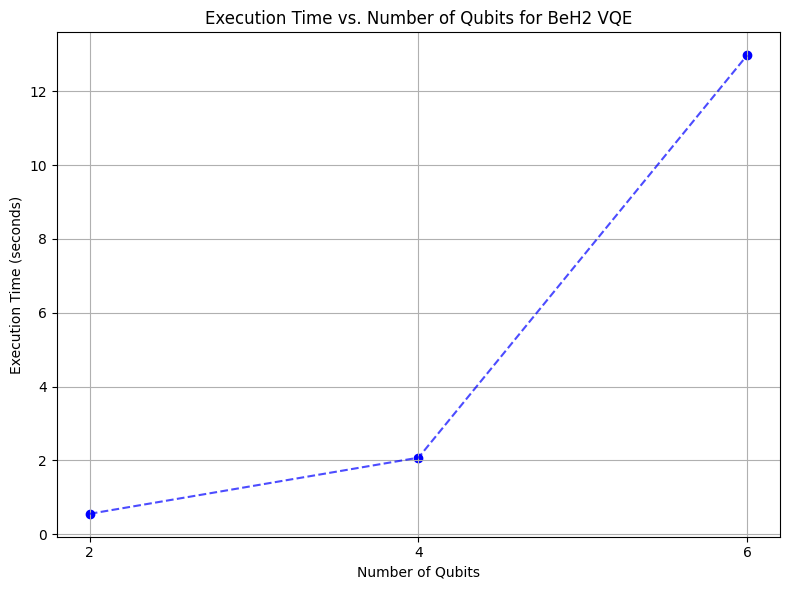

In [18]:
import matplotlib.pyplot as plt

num_qubits_list = [res['num_qubits'] for res in results]
execution_time_list = [res['execution_time'] for res in results]

plt.figure(figsize=(8, 6))
plt.scatter(num_qubits_list, execution_time_list, marker='o', color='blue')
plt.plot(num_qubits_list, execution_time_list, linestyle='--', color='blue', alpha=0.7)

plt.title('Execution Time vs. Number of Qubits for BeH2 VQE')
plt.xlabel('Number of Qubits')
plt.ylabel('Execution Time (seconds)')
plt.grid(True)
plt.xticks(num_qubits_list)
plt.tight_layout()
plt.show()
